# Convert Spike Train to Electrical Stimulus Sequence

In [1]:
%reload_ext autoreload
%autoreload 2

# Imports
import numpy as np
import visionloader as vl
import matplotlib.pyplot as plt
import os
import matplotlib.cm as cm
from tqdm import tqdm
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse
import scipy as sp

In [2]:
# piece = '2013-05-28-3'
# analysis_base = f"/Volumes/Analysis/{piece}"

# wnoise = "data000"
# vstim = "data003"
# cell_types = ['ON parasol', 'OFF parasol']

# dict_path = os.path.join(analysis_base, 'dictionary')
# vstim_path = os.path.join(analysis_base, vstim)
# wnoise_path = os.path.join(analysis_base, wnoise)

In [3]:
piece = '2024-07-18-0'
analysis_base = f"/Volumes/Stream/Analysis/RETINA/{piece}"

wnoise = "data001"
vstim = "data003_from_data001"
cell_types = ['ON alpha', 'OFF alpha']

dict_path = os.path.join(analysis_base, 'dictionary')
vstim_path = os.path.join(analysis_base, vstim)
wnoise_path = os.path.join(analysis_base, wnoise)

### Load electrical stimulus table

In [4]:
selective_stimuli = np.load(os.path.join(dict_path, f"selective_stimuli.npz"))['selective_stimuli'] # selective_stimuli row is [electrode, cell, amp, pure]

### Determine spike trains of interest

In [5]:
wnoise_vcd = vl.load_vision_data(wnoise_path,wnoise,
                        include_neurons=True,
                        include_ei=True,
                        include_params=True,
                        include_runtimemovie_params=True)

coords = wnoise_vcd.get_electrode_map()

# coords_path = "/Volumes/Lab/Users/ajphillips/greedy/src/coords.npy"
# coords = np.load(coords_path)

In [6]:
vcd = vl.load_vision_data(vstim_path,vstim,
                        include_neurons=True)
                        # include_ei=True,
                        # include_params=True,
                        # include_runtimemovie_params=True)

In [7]:
# Get all cell IDs from cell types of interest
# cell_ids = []
# for cell_type in cell_types:
#     cell_ids.extend(vcd.get_all_cells_similar_to_type(cell_type))
# cell_ids = np.array(cell_ids)

# Get all selective cell IDs
cell_ids = np.unique(selective_stimuli[:,1])

spike_times = np.array([vcd.get_spike_times_for_cell(c) for c in cell_ids], dtype=object) / 20 # convert to seconds

print(spike_times.shape)

(53,)


In [8]:
ttl_times = vcd.ttl_times / 20 # convert to seconds
np.set_printoptions(suppress=True)
print(ttl_times)

[   538.2    7557.8    8043.3   15063.35  15532.1   22552.    23037.65
  30057.7   30543.    37563.3   38032.05  45052.05  45529.5   52549.1
  53034.7   60054.8   60540.2   67560.    68029.    75048.95  75534.45
  82554.65  83040.    90060.1   90537.2   97557.35  98034.3  105054.6
 105540.   112560.1  113028.8  120048.6  120534.25 127554.6  128031.
 135051.65 135528.7  142548.75 143034.15 150054.05 150531.4  151033.3
 151535.05 152037.45 152539.45 153041.15 153543.5  154045.6  154547.45
 155049.35 155551.65 156053.5  156555.75 157057.65 157559.65 158061.7
 158563.65 159066.1  159567.7  160070.05 160571.9  161102.7  161601.15
 162103.25 162605.25 163107.55 163609.35 164111.6  164613.35 165115.6
 165617.75 166120.05 166621.6  167123.7  167625.75 168127.85 168629.6
 169131.75 169634.   170135.65 170637.75 171140.15 171641.95 172143.8
 172646.25 173148.35 173650.35 174152.5  174654.45 175156.45 176026.7
 176528.8  177030.75 177532.95 178034.5  178536.7  179038.9  179541.1
 180042.75 180544

In [9]:
responses = []
for j in range(len(ttl_times)-1):
    low = ttl_times[j]
    high = ttl_times[j+1]
    filtered_spike_times = np.array([spike_time[(low < spike_time) & (spike_time < high)] for spike_time in spike_times], dtype=object)
    responses.append(filtered_spike_times)

In [10]:
print(len(responses))

539


In [11]:
print(ttl_times[36:43])

[135528.7  142548.75 143034.15 150054.05 150531.4  151033.3  151535.05]


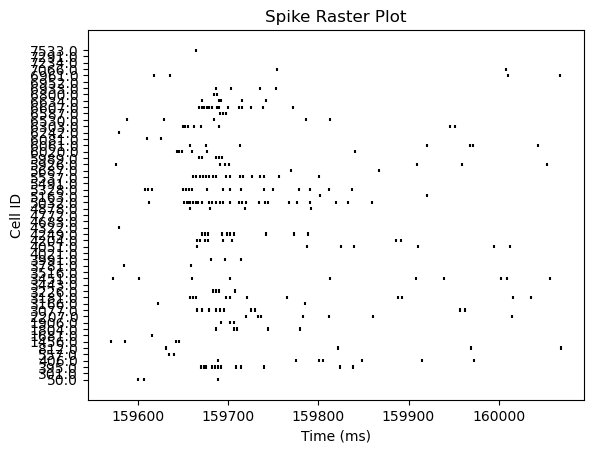

In [12]:
response = responses[58]
    
# Create a spike raster plot
plt.eventplot(response, linelengths=0.5, colors='black')

# Set the y-axis ticks and labels
plt.yticks(range(len(cell_ids)), cell_ids)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Spike Raster Plot')

# Show the plot
plt.show()

Response 1:


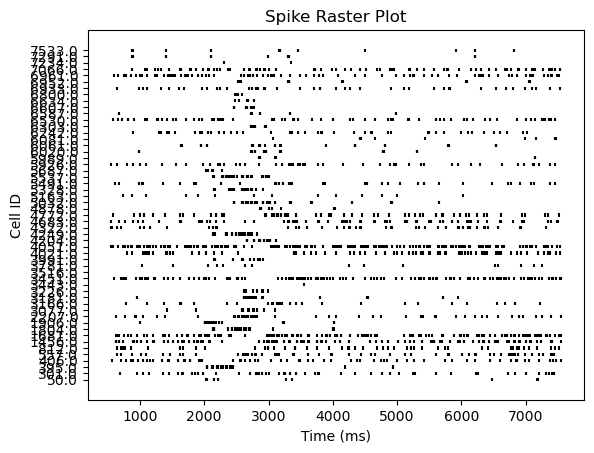

Response 2:


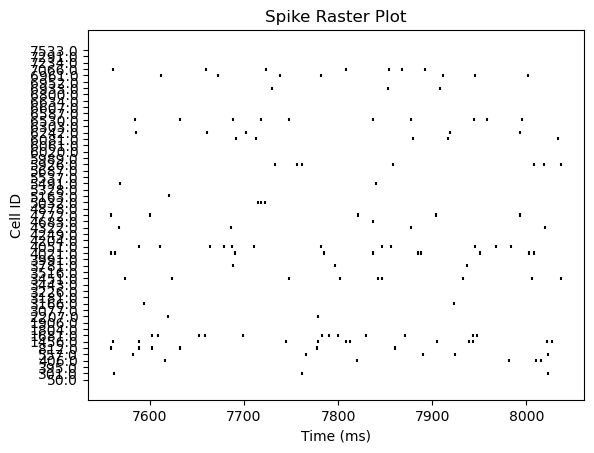

Response 3:


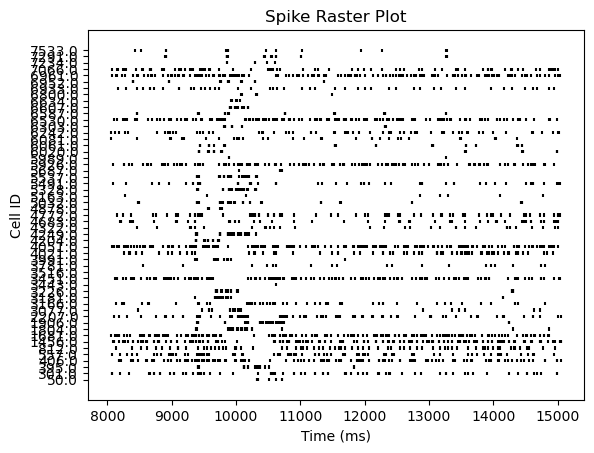

Response 4:


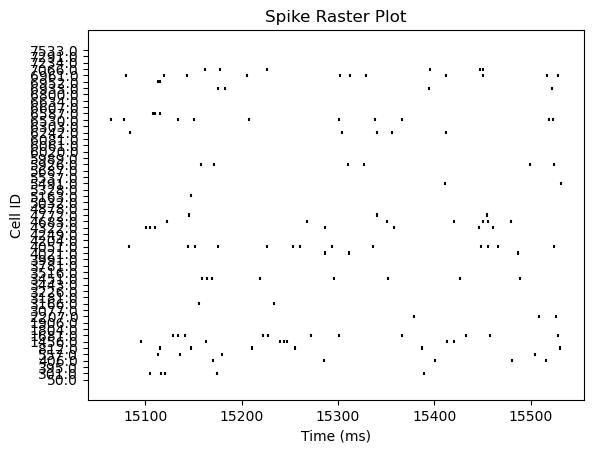

Response 5:


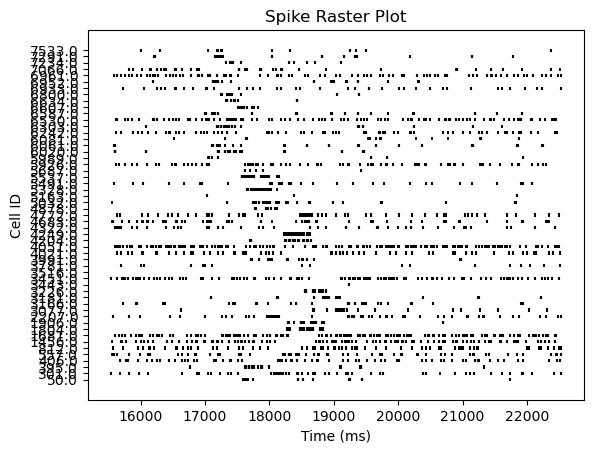

Response 6:


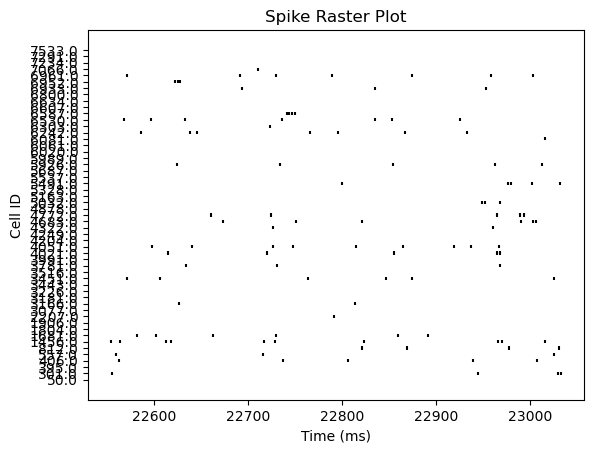

Response 7:


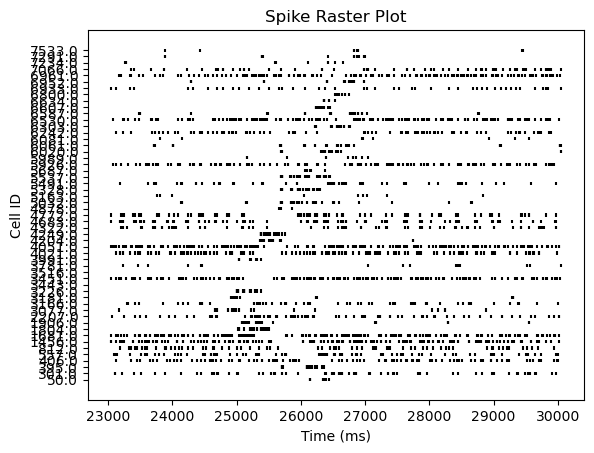

Response 8:


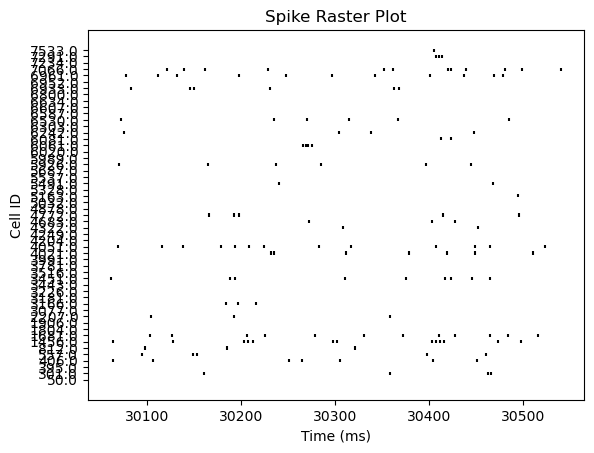

Response 9:


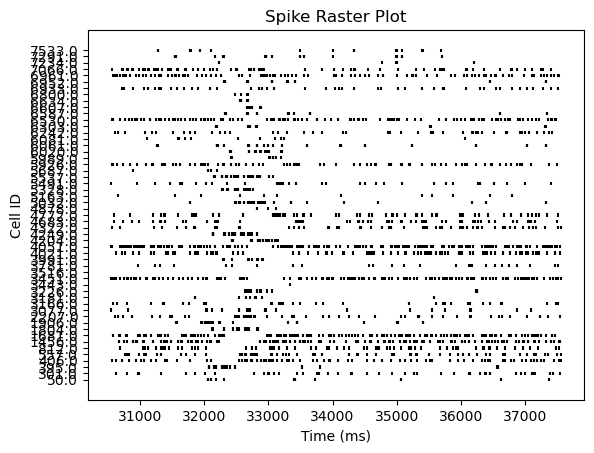

Response 10:


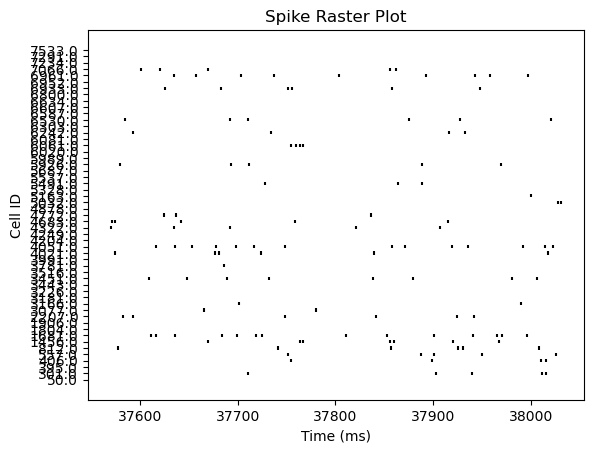

Response 11:


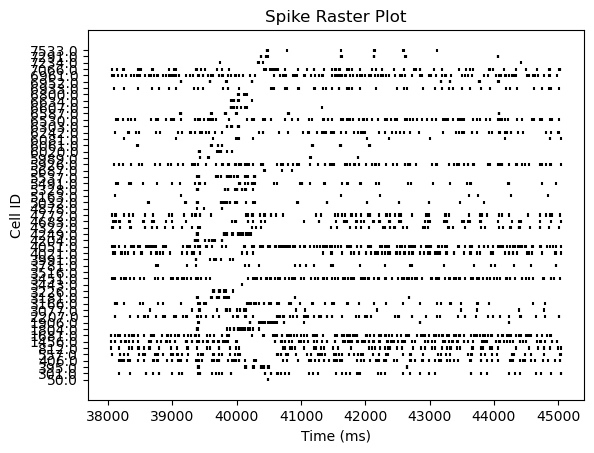

In [13]:
for i, response in enumerate(responses):
    if i > 10:
        break

    print(f"Response {i+1}:")
    
    # Create a spike raster plot
    plt.eventplot(response, linelengths=0.5, colors='black')

    # Set the y-axis ticks and labels
    plt.yticks(range(len(cell_ids)), cell_ids)
    plt.ylabel('Cell ID')

    # Set the x-axis label
    plt.xlabel('Time (ms)')

    # Set the plot title
    plt.title('Spike Raster Plot')

    # Show the plot
    plt.show()

In [14]:
# responses 8, 10, 12, 14, 39-58...
response = responses[58]

# min_interspike_interval = np.array([np.min(np.diff(cell_spike_times)) for cell_spike_times in response])
min_interspike_interval = []
for i, cell_spike_times in enumerate(response):
    try:
        min_interspike_interval.append(np.min(np.diff(response[i])))
    except:
        continue
min_interspike_interval = np.array(min_interspike_interval)

average_interspike_interval = np.array([np.mean(np.diff(cell_spike_times)) for cell_spike_times in response])

proportions = []
for cell_spike_times in response:
    intervals = np.diff(cell_spike_times)
    proportion = np.mean(intervals < 2.5)
    proportions.append(proportion)
proportions = np.array(proportions)

print("Minimum Interspike Interval:")
print(min_interspike_interval)
print(np.mean(min_interspike_interval))

print("Average Interspike Interval:")
print(average_interspike_interval)
print(np.nanmean(average_interspike_interval))

print("Percentage of Interspike Intervals < 2.5 ms:")
print(proportions*100)
print(np.nanmean(proportions)*100)

Minimum Interspike Interval:
[  7.1    2.75   4.95   4.85 100.85   3.45   3.15   4.05   3.8    4.2
 163.9    3.3    3.15   6.6   73.55  15.7   15.2    2.9    2.9   22.7
   1.1  118.45   3.15   3.25  97.25   4.8    3.25   2.95   3.65  15.35
   2.8   27.15   2.75   2.6    2.8    3.45  16.25  17.25 253.9 ]
26.441025641025192
Average Interspike Interval:
[ 44.825               nan  15.31818182  47.3          4.85
 146.33333333  25.31666667          nan  23.475        7.425
  49.325       33.06111111 163.9         37.845        8.15
          nan  53.92777778          nan  73.55        16.75
          nan  57.975       32.32142857  13.05                nan
          nan          nan  44.81666667   9.49038462 118.45
  14.346875            nan   8.75625     97.25        79.64166667
   6.35        39.57        64.41666667  15.35                nan
  43.22857143  56.45         2.975        7.95769231  17.7
   3.45        22.23333333          nan 150.3        253.9
          nan          nan    

/Volumes/Lab/Development/anaconda3/envs/RETINA/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Volumes/Lab/Development/anaconda3/envs/RETINA/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [15]:
bin_size_ms = 2.5
rounded_response = np.array([np.round(cell_spike_times / bin_size_ms) * bin_size_ms for cell_spike_times in response], dtype=object)

print(rounded_response.shape)

(53,)


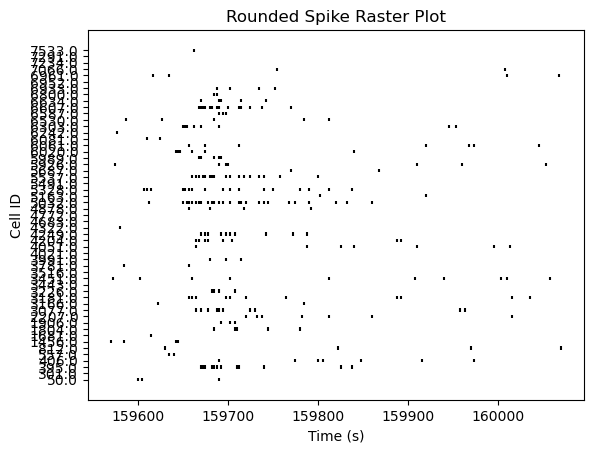

In [16]:
# Create a spike raster plot
plt.eventplot(rounded_response, linelengths=0.5, colors='black')

# Set the y-axis ticks and labels
plt.yticks(range(len(cell_ids)), cell_ids)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (s)')

# Set the plot title
plt.title('Rounded Spike Raster Plot')

# Show the plot
plt.show()

In [17]:
print(rounded_response)

[array([159600., 159605., 159690.]) array([], dtype=float64)
 array([159670. , 159672.5, 159675. , 159682.5, 159685. , 159687.5,
        159692.5, 159710. , 159712.5, 159740. , 159825. , 159837.5])
 array([159690. , 159775. , 159800. , 159805. , 159847.5, 159915. ,
        159972.5])
 array([159635., 159640.]) array([159630. , 159822.5, 159970. , 160070. ])
 array([159570. , 159585. , 159642.5, 159645. ]) array([159615.])
 array([159685. , 159707.5, 159710. , 159745. , 159780. ])
 array([159692.5, 159702.5, 159707.5])
 array([159720. , 159732.5, 159737.5, 159782.5, 159812.5, 159860. ,
        160015. ])
 array([159665. , 159670. , 159677.5, 159687.5, 159690. , 159695. ,
        159725. , 159730. , 159957.5, 159962.5])
 array([159622.5, 159785. ])
 array([159657.5, 159660. , 159665. , 159697.5, 159702.5, 159720. ,
        159765. , 159887.5, 159892.5, 160015. , 160035. ])
 array([159682.5, 159685. , 159690. , 159707.5]) array([], dtype=float64)
 array([159572.5, 159602.5, 159660. , 1597

In [22]:
from collections import Counter

def assign_stimuli_to_responses(response, cell_ids, selective_stimuli, plot=False):
    # responses is a list of arrays of spike times for each cell
    # cell_ids is an array of cell IDs
    # selective_stimuli is an array of selective stimuli

    concat_response = np.concatenate(response)

    max_n = Counter(concat_response).most_common(1)[0][1]
    print(f"Maximum number of simultaneous cells firing: {max_n}")

    concat_spike_times = np.unique(concat_response)
    print(f"Unique stimulus times: {concat_spike_times.size}")

    sef = np.empty((0,3))

    for t in concat_spike_times:
        print("-------------------")
        print(f"Stimulus time: {t}")
        # Determine which of the response arrays contain the stimulus time
        response_indices = [i for i, cell_spike_times in enumerate(response) if t in cell_spike_times]
        cell_ids_for_stimulus = cell_ids[response_indices]
        print(f"Cell IDs: {cell_ids_for_stimulus}")
        # Report and remove any cell IDs that are not in the selective stimuli
        if len([cell_id for cell_id in cell_ids_for_stimulus if cell_id not in selective_stimuli[:,1]]) > 0:
            print(f"Can't selectively stimulate cell IDs: {[cell_id for cell_id in cell_ids_for_stimulus if cell_id not in selective_stimuli[:,1]]}")
        cell_ids_for_stimulus = np.array([cell_id for cell_id in cell_ids_for_stimulus if cell_id in selective_stimuli[:,1]])

        # Continue if there are no cell IDs to stimulate
        if cell_ids_for_stimulus.size == 0:
            print("Skipping stimulus time...")
            continue

        sef = np.vstack((sef, assign_stimuli(t, cell_ids_for_stimulus, selective_stimuli, plot)))

    return sef


def assign_stimuli(t, cell_ids_for_stimulus, selective_stimuli, plot):
    # selective_stimuli row is [electrode, cell, amp, pure]
    # sef row is [time, electrode, amp]

    # Find the selective stimuli that match the cell IDs
    matching_stimuli = []
    for cell_id in cell_ids_for_stimulus:
        matching_stimuli.extend([stimulus for stimulus in selective_stimuli if stimulus[1] == cell_id])
    matching_stimuli = np.array(matching_stimuli)

    if len(cell_ids_for_stimulus) == 1:
        print(f"Selected electrodes: {matching_stimuli[0,0].astype(int)}")
        return [t, matching_stimuli[0,0], matching_stimuli[0,2]]

    # Find the convex hull of the electrodes in the matching stimuli on the electrode array
    electrodes = np.array([stimulus[0] for stimulus in matching_stimuli])
    electrodes = electrodes.astype(int)

    if len(electrodes) == 2:
        print(f"Selected electrodes: {electrodes.astype(int)}")
        return np.array([[t, matching_stimuli[0,0], matching_stimuli[0,2]], 
                        [t, matching_stimuli[1,0], matching_stimuli[1,2]]])

    # points = coords[electrodes]
    # convex_hull = sp.spatial.ConvexHull(points)

    # Plot the convex hull and the electrodes
    if plot:
        fig, ax = plt.subplots()
        ax.plot(coords[:,0], coords[:,1], 'k.')
        # for simplex in convex_hull.simplices:
        #     ax.plot(points[simplex, 0], points[simplex, 1], 'k-')

        # Plot the electrodes corresponding to each cell_id in different colors
        colors = cm.rainbow(np.linspace(0, 1, len(cell_ids_for_stimulus)))
        for i, cell_id in enumerate(cell_ids_for_stimulus):
            cell_id_elecs = matching_stimuli[np.where(matching_stimuli[:,1] == cell_id)[0]][:,0].astype(int)
            ax.plot(coords[cell_id_elecs-1,0], coords[cell_id_elecs-1,1], 'o', color=colors[i])


        # For each cell_id, find the electrode that activates it that is closest to the convex hull
        # closest_electrodes = []
        # for i, cell_id in enumerate(cell_ids_for_stimulus):
        #     cell_id_elecs = matching_stimuli[np.where(matching_stimuli[:,1] == cell_id)[0]][:,0].astype(int)
        #     index = np.unravel_index(np.argmin(sp.spatial.distance.cdist(points[convex_hull.vertices], coords[cell_id_elecs])), 
        #                              sp.spatial.distance.cdist(points[convex_hull.vertices], coords[cell_id_elecs]).shape)
        #     closest_electrode = cell_id_elecs[index[1]]
        #     closest_electrodes.append(closest_electrode)
        #     # Designate these electrodes on the plot
        #     ax.plot(coords[closest_electrode,0], coords[closest_electrode,1], 'x', color=colors[i], markersize=10)

    # For the first two cells, find an electrode for each of the cells that activates the cell and is farthest away from the other found electrode
    selected_electrodes = []
    cell_id_elecs0 = matching_stimuli[np.where(matching_stimuli[:,1] == cell_ids_for_stimulus[0])[0]][:,0].astype(int)
    cell_id_elecs1 = matching_stimuli[np.where(matching_stimuli[:,1] == cell_ids_for_stimulus[1])[0]][:,0].astype(int)
    distances = sp.spatial.distance.cdist(coords[cell_id_elecs0-1], coords[cell_id_elecs1-1])
    index = np.unravel_index(np.argmax(distances), distances.shape)
    selected_electrode = cell_id_elecs0[index[0]]
    selected_electrodes.append(selected_electrode)
    if plot:
        ax.plot(coords[selected_electrode-1,0], coords[selected_electrode-1,1], 'X', color=colors[0], markersize=15)
    selected_electrode = cell_id_elecs1[index[1]]
    selected_electrodes.append(selected_electrode)
    if plot:
        ax.plot(coords[selected_electrode-1,0], coords[selected_electrode-1,1], 'X', color=colors[1], markersize=15)


    # Find an electrode for each of the remaining cell IDs that activates the cell and is farthest away from all other found electrodes
    for i, cell_id in enumerate(cell_ids_for_stimulus):
        if i < 2:
            continue
        cell_id_elecs = matching_stimuli[np.where(matching_stimuli[:,1] == cell_id)[0]][:,0].astype(int)
        distances = sp.spatial.distance.cdist(coords[cell_id_elecs-1], coords[np.array(selected_electrodes)-1])
        index = np.argmax(np.sum(distances, axis=1))
        selected_electrode = cell_id_elecs[index]
        selected_electrodes.append(selected_electrode)
        # Designate these electrodes on the plot
        if plot:
            ax.plot(coords[selected_electrode-1,0], coords[selected_electrode-1,1], 'X', color=colors[i], markersize=15)

    if plot:
        ax.set_aspect('equal')
        plt.show()

    print(f"Selected electrodes: {selected_electrodes}")

    to_return = np.empty((0,3))
    for i, cell_id in enumerate(cell_ids_for_stimulus):
        to_return = np.vstack((to_return, [t, selected_electrodes[i], matching_stimuli[np.where(matching_stimuli[:,0:1] == [selected_electrodes[i], cell_id])[0][0],2]]))
    return to_return

def convert_sef_to_board(sef):
    amplitudes = np.array([0.09375, 0.1875, 0.28125, 0.375, 0.46875, 0.5625, 0.65625, 0.75, 0.84375, 0.9375,
            1.03125, 1.125, 1.21875, 1.3125, 1.40625, 1.5, 1.59375, 1.6875, 1.78125, 1.875, 1.96875,
            2.0625, 2.15625, 2.25, 2.34375, 2.4375, 2.53125, 2.625, 2.71875, 2.8125, 2.90625, 3.0,
            3.09375, 3.1875, 3.28125, 3.375, 3.46875, 3.5625, 3.65625, 3.75, 3.84375, 3.9375])

    # Subtract time 0 from all times
    board_sef = sef.copy()
    board_sef[:,0] -= board_sef[0,0]
    board_sef[:,0] *= 20

    # Avoid multiples of the stimulation window boundary
    board_sef[:,0] += 1

    # Find the index of the closest amplitude to the amplitude in the sef
    for i in range(board_sef.shape[0]):
        board_sef[i,2] = np.argmin(np.abs(amplitudes - board_sef[i,2])) + 1 # 1-indexed

    board_sef = board_sef.astype(int)
    return board_sef

In [334]:
# Make up data for selective_stimuli
# n_rows = 20
# selective_stimuli = np.zeros((n_rows, 4))
# selective_stimuli[:,0] = np.random.randint(0, 512, n_rows)
# selective_stimuli[:,1] = np.random.choice(cell_ids, n_rows)
# selective_stimuli[:,2] = np.random.rand(n_rows)
# selective_stimuli[:,3] = 1
# print(selective_stimuli)

In [24]:
sef = convert_sef_to_board(assign_stimuli_to_responses(rounded_response,cell_ids,selective_stimuli,plot=False))

Maximum number of simultaneous cells firing: 11
Unique stimulus times: 116
-------------------
Stimulus time: 159570.0
Cell IDs: [1456.]
-------------------
Stimulus time: 159572.5
Cell IDs: [3451.]
-------------------
Stimulus time: 159575.0
Cell IDs: [5926.]
-------------------
Stimulus time: 159577.5
Cell IDs: [6242.]
-------------------
Stimulus time: 159580.0
Cell IDs: [4322.]
-------------------
Stimulus time: 159585.0
Cell IDs: [1456. 3781.]
-------------------
Stimulus time: 159587.5
Cell IDs: [6530.]
-------------------
Stimulus time: 159600.0
Cell IDs: [50.]
-------------------
Stimulus time: 159602.5
Cell IDs: [3451.]
-------------------
Stimulus time: 159605.0
Cell IDs: [50.]
-------------------
Stimulus time: 159607.5
Cell IDs: [5328.]
-------------------
Stimulus time: 159610.0
Cell IDs: [5328. 6081.]
-------------------
Stimulus time: 159612.5
Cell IDs: [5032.]
-------------------
Stimulus time: 159615.0
Cell IDs: [1681. 5328.]
-------------------
Stimulus time: 159617.5

In [20]:
print(sef)

[[    1    98    19]
 [   51   230     6]
 [  101   373    22]
 [  151     5    19]
 [  201   273    13]
 [  301    98    19]
 [  301   253    25]
 [  351   428    33]
 [  601     8    33]
 [  651   230     6]
 [  701     8    33]
 [  751    70    26]
 [  801   119    39]
 [  801   425    36]
 [  851   336    13]
 [  901   161    41]
 [  901    70    26]
 [  951   465    30]
 [ 1051   205    37]
 [ 1101   425    36]
 [ 1151   428    33]
 [ 1201    92    15]
 [ 1301   112    13]
 [ 1301   465    30]
 [ 1401   112    13]
 [ 1451    98    19]
 [ 1451   402    26]
 [ 1501    98    19]
 [ 1501   402    26]
 [ 1551   352    36]
 [ 1601   336    13]
 [ 1601   119    39]
 [ 1601   421    10]
 [ 1651   119    39]
 [ 1651   421    10]
 [ 1701   336    13]
 [ 1701   421    10]
 [ 1751   281     9]
 [ 1751   253    25]
 [ 1751   326    21]
 [ 1751   336    13]
 [ 1751   119    39]
 [ 1751   414    40]
 [ 1801   281     9]
 [ 1801   230     6]
 [ 1801   336    13]
 [ 1801   119    39]
 [ 1801   374

In [337]:
# all_sef_arrays = []

In [338]:
all_sef_arrays.append(sef)
print(len(all_sef_arrays))

24


In [360]:
num_repeats = 15
all_sef_arrays_repeat = [sef.astype(np.int32) for sef in all_sef_arrays for _ in range(num_repeats)]

In [361]:
# Add 300 to the first SEF sequence to give adequate time for the initial current range setting [1 0 -4]
all_sef_arrays_repeat[0][:,0] += 300
all_sef_arrays_repeat = np.array(all_sef_arrays_repeat, dtype=object)

save_path = os.path.join(dict_path, "spike_trains.npz")
np.savez(save_path, sef=all_sef_arrays_repeat, allow_pickle=True)